In [ ]:
# THE STORAGE

""" print("================== CORRELATION MATRIX ==================")
corr = x_training_df[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


print("================== Feature Importance ==================")
best_model = grid_search.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances (XGBoost)")
plt.tight_layout()
plt.show()


print("================== Confusion matrix ==================")
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_, x_test_df, y_test,
    display_labels=["blue won", "red won"],
    cmap="Blues"
)
plt.show()


print("================== ROC curve + AUC ==================")
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(grid_search.best_estimator_, x_test_df, y_test)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # random baseline
plt.title("ROC curve")
plt.show()


print("================== Precision/recall + full classification report ==================")
from sklearn.metrics import classification_report

y_pred = grid_search.best_estimator_.predict(x_test_df)
print(classification_report(y_test, y_pred, target_names=["blue won", "red won"]))


print("================== Learning curve (over/underfitting check) ==================")
results = pd.DataFrame(grid_search.cv_results_)
sns.lineplot(data=results, x="param_clf__max_depth", y="mean_train_score", label="train")
sns.lineplot(data=results, x="param_clf__max_depth", y="mean_test_score", label="validation")
plt.title("Train vs validation score by max_depth")
plt.show() """

Setup stuff

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

data_frame = pd.read_csv("C:/Users/tumik/Documents/semester 5/machine learning/project1_repo/MachineLearningRepo/Project1/data/all_fights.csv")


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]
#print(data_frame["weight_class"].value_counts())


# ============

# getting all features with diff 
diff_features_df = data_frame.filter(regex=r'_diff')
#diff_features_df.info()


#TODO: Other attributes than diff that we will keep
# red_winner, gender, weight_class, red_stance, blue_stance, red_age, blue_age
extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", "blue_age", "fight_date"
]
extra_features_df = data_frame[extra_features]
#extra_features_df.info()


feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)
#feature_selected_df.info()

#NOTE: maybe no buckets
# adding age buckets
bins = [17, 23, 27, 33, float("inf")]
labels = ["18-23", "24-27", "28-33", "34+"]

feature_selected_df["red_age_bucket"] = pd.cut(
    data_frame["red_age"],
    bins=bins,
    labels=labels
)

feature_selected_df["blue_age_bucket"] = pd.cut(
    data_frame["blue_age"],
    bins=bins,
    labels=labels
)

#print(feature_selected_df["red_age_bucket"].value_counts())
#print(feature_selected_df["blue_age_bucket"].value_counts())

# drop red_ and blue_age
feature_selected_df = feature_selected_df.drop(columns=['red_age'])
feature_selected_df = feature_selected_df.drop(columns=['blue_age'])
# drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=['odds_diff'])

#feature_selected_df.info()

#NOTE: class variable??
class_df = data_frame[["red_winner","fight_date"]]
#class_df.info()

#NOTE: split the data based on fight date
DATE = "2023-06-01"
SPLIT_DATE = r"2023-06-01"

# splitting the data thing
x_training_df = feature_selected_df.loc[feature_selected_df['fight_date'] <= SPLIT_DATE]
x_test_df  = feature_selected_df.loc[feature_selected_df['fight_date'] > SPLIT_DATE]

# drop fight_date
x_training_df = x_training_df.drop(columns=['fight_date'])
x_test_df = x_test_df.drop(columns=['fight_date'])

#x_training_df.info()

# splitting the class thing
y_training_df = class_df.loc[class_df['fight_date'] <= SPLIT_DATE]
y_test_df  = class_df.loc[class_df['fight_date'] > SPLIT_DATE]

# drop fight_date
y_training_df = y_training_df.drop(columns=['fight_date'])
y_test_df = y_test_df.drop(columns=['fight_date'])


#### Trying models

In [ ]:
#
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report

# your categorical columns (everything that's object/category dtype)
cat_features = ["gender", "weight_class", "red_stance", "blue_stance",
                "red_age_bucket", "blue_age_bucket"]

# cat_features = ["gender", "weight_class", "red_stance", "blue_stance",
#                 "red_age", "blue_age"]


# CatBoost needs cats as string, and no NaNs in cat columns (fill or drop first)
for col in cat_features:
    x_training_df[col] = x_training_df[col].astype(str)
    x_test_df[col] = x_test_df[col].astype(str)

# y needs to be 1D, not a single-column dataframe
y_train = y_training_df["red_winner"]
y_test = y_test_df["red_winner"]

train_pool = Pool(x_training_df, y_train, cat_features=cat_features)
test_pool = Pool(x_test_df, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="Accuracy",
    random_seed=26,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

preds = model.predict(x_test_df)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

# feature importance
importances = model.get_feature_importance(train_pool, prettified=True)
print(importances)

0:	learn: 0.5890967	test: 0.6039604	best: 0.6039604 (0)	total: 69.4ms	remaining: 34.6s
100:	learn: 0.6506704	test: 0.6059406	best: 0.6092409 (88)	total: 9.62s	remaining: 38s
200:	learn: 0.6859562	test: 0.6092409	best: 0.6145215 (152)	total: 20.3s	remaining: 30.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6145214521
bestIteration = 152

Shrink model to first 153 iterations.
0.6145214521452145
              precision    recall  f1-score   support

           f       0.62      0.35      0.45       673
           t       0.61      0.82      0.70       842

    accuracy                           0.61      1515
   macro avg       0.61      0.59      0.58      1515
weighted avg       0.61      0.61      0.59      1515

                 Feature Id  Importances
0                  age_diff    14.774584
1                   td_diff    10.400961
2              sig_str_diff     9.071490
3                reach_diff     5.625799
4               losses_diff     5.388982
5     

In [19]:
""" import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

cat_features = ["gender", "weight_class", "red_stance", "blue_stance",
                "red_age_bucket", "blue_age_bucket"]

x_train_enc = pd.get_dummies(x_training_df, columns=cat_features)
x_test_enc = pd.get_dummies(x_test_df, columns=cat_features)

# align columns — test set might be missing a category train set had, or vice versa
x_train_enc, x_test_enc = x_train_enc.align(x_test_enc, join="left", axis=1, fill_value=0)

y_train = y_training_df["red_winner"]
y_test = y_test_df["red_winner"]

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=26
)

model.fit(
    x_train_enc, y_train,
    eval_set=[(x_test_enc, y_test)],
    verbose=100
)

preds = model.predict(x_test_enc)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

# feature importance
xgb.plot_importance(model, max_num_features=15)
plt.show() """

' import xgboost as xgb\nfrom sklearn.metrics import accuracy_score, classification_report\n\ncat_features = ["gender", "weight_class", "red_stance", "blue_stance",\n                "red_age_bucket", "blue_age_bucket"]\n\nx_train_enc = pd.get_dummies(x_training_df, columns=cat_features)\nx_test_enc = pd.get_dummies(x_test_df, columns=cat_features)\n\n# align columns — test set might be missing a category train set had, or vice versa\nx_train_enc, x_test_enc = x_train_enc.align(x_test_enc, join="left", axis=1, fill_value=0)\n\ny_train = y_training_df["red_winner"]\ny_test = y_test_df["red_winner"]\n\nmodel = xgb.XGBClassifier(\n    n_estimators=500,\n    learning_rate=0.05,\n    max_depth=6,\n    eval_metric="logloss",\n    early_stopping_rounds=50,\n    random_state=26\n)\n\nmodel.fit(\n    x_train_enc, y_train,\n    eval_set=[(x_test_enc, y_test)],\n    verbose=100\n)\n\npreds = model.predict(x_test_enc)\nprint(accuracy_score(y_test, preds))\nprint(classification_report(y_test, preds)

### CHAT PLOT - weight_class distribution after split

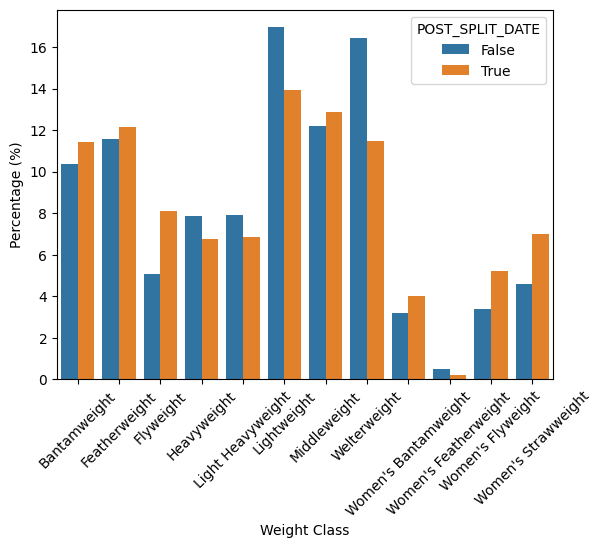

In [20]:
data_frame["POST_SPLIT_DATE"] = data_frame["fight_date"] > SPLIT_DATE

percentage_df = (
    data_frame
    .groupby(["POST_SPLIT_DATE", "weight_class"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .reset_index(name="percentage")
)

sns.barplot(
    data=percentage_df,
    x="weight_class",
    y="percentage",
    hue="POST_SPLIT_DATE"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Weight Class")
plt.xticks(rotation=45)
plt.show()

### random test stuff

In [21]:
#NOTE: random tests

##NOTE: combining fight stances - does not needed
#data_frame["stance_diff"] = data_frame["red_stance"] + "-" + data_frame["blue_stance"]
#stance_diff = data_frame['stance_diff'].unique()
#print(stance_diff)

#blue_stance = data_frame['blue_stance'].unique()
#gender = data_frame['gender'].unique()
#weight_class = data_frame['weight_class'].unique()
#print(weight_class)
#print(blue_stance)

#diff_only_df = diff_only_df.drop((diff_only_df["blue_stance"] == "Unknown")) 
#| (data_frame["blue_stance"] == "Switch ") | (data_frame["blue_stance"] == "Open Stance ")]

#for i in weight_class:
#    print(i)

#focked = data_frame[(data_frame["blue_stance"] == "Unknown") | (data_frame["blue_stance"] == "Switch ")]

#focked = data_frame[(data_frame["weight_class"] == "Catch Weight")]
#print(focked)
#print(focked.shape)

#print(data_frame[data_frame["blue_stance"] == "Unknown"])


#NOTE STUFF FROM FIRST CELL
#y_training_df.info()

#print(x_training_df.head)

""" data_count = data_frame.shape[0]
training_count = data_frame_training.shape[0]
test_count = data_frame_testing.shape[0]

print(f"Data is split on fights before {SPLIT_DATE} and after {SPLIT_DATE}")
print("Training Data")
print(f"Before {SPLIT_DATE} | size : {training_count} | Percent of total : {((training_count / data_count)*100):.2f}%")
print("Test Data")
print(f"After  {SPLIT_DATE} | size : {test_count} | Percent of total : {((test_count / data_count)*100):.1f}%") """



# splitting data
# find date of
""" x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=26
) """

' x_train, x_test, y_train, y_test = train_test_split(\n    x,\n    y,\n    test_size=0.2,\n    stratify=y,\n    random_state=26\n) '

### NON-diff categories that we might want to keep
red_winner


#### total classes
14 * 2 * 3 * 8 = 

#### weight_class
drop catch weight?

Flyweight
Welterweight
Heavyweight
Featherweight
Light Heavyweight
Catch Weight // dropped
Lightweight
Bantamweight
Women's Strawweight
Women's Flyweight
Middleweight
Women's Bantamweight
Women's Featherweight
total 14

#### gender
'MALE'
'FEMALE'
total 2

#### blue_ and red_ stance

drop 'Switch ' 'Open Stance' 'Unknown'

orth - orth
orth - south
orth - switch
south - south
south - switch
switch - switch

total 6

#### blue_ and red_ age
18-23 
24-27 
28-33
33+

total 8

In [22]:
#focked = data_frame[(data_frame["reach_diff"] < -30) | (data_frame["reach_diff"] > 30)]
#print(focked)
#print(focked.shape)


## Plot tests

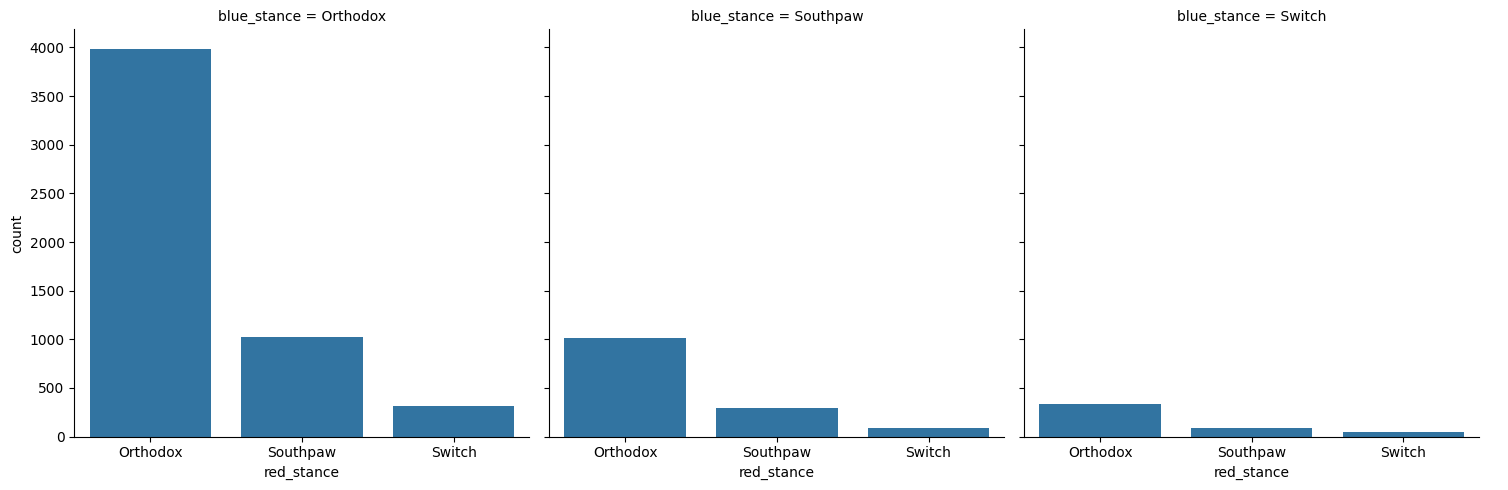

In [23]:
""" sns.countplot(
    data=data_frame,
    y='red_stance',
    x='blue_stance',
    # order=df['category'].value_counts().index
) """

sns.catplot(
    data=data_frame,
    x="red_stance",
    #y="red_winner",
    col="blue_stance",
    kind="count",
    col_wrap=3
)

""" sns.catplot(
    data=df_analysis,
    x="pclass",
    y="survived",
    col="who",
    kind="bar"
) """

plt.show()

#### How to split the data


#### How to split the data into training / test set?


#### What is the benchmark you will compare your model with?


#### Which models have a good chance of working well on this data set?


#### What preprocessing needs to be done to use these models?


#### How to set the hyperparameters of these models and/or which range of values for the hyperparameters should be tried?


#### How to evaluate the different models to decide on the best one?



In [24]:
""" # TRAINING
train_df = pd.DataFrame({
    "target": y_train,
    "data": x_train
})

train_df["class"] = train_df["target"].map(
    lambda x: newsgroups.target_names[x]
)

train_class_count = train_df['target'].value_counts().sort_index()
train_result = pd.DataFrame({
    "class": newsgroups.target_names,
    "count": train_class_count,
    "share": train_class_count / len(train_df) * 100
})
#print(train_result)
#print("total count: ", train_result["count"].sum())

# TEST
test_df = pd.DataFrame({
    "target": y_test,
    "data": x_test
})

test_df["class"] = test_df["target"].map(
    lambda x: newsgroups.target_names[x]
)

test_class_count = test_df['target'].value_counts().sort_index()
test_result = pd.DataFrame({
    "class": newsgroups.target_names,
    "count": test_class_count,
    "share": test_class_count / len(test_df) * 100
})

#print(test_result)
#print("total count: ", test_result["count"].sum())

train_result["dataset"] = "Train"
test_result["dataset"] = "Test"
combined = pd.concat([train_result, test_result])

sns.barplot(
    data=combined,
    x="share",
    y="class",
    hue="dataset"
)

plt.xlabel("Percentage")
plt.ylabel("Class")

plt.show() """

' # TRAINING\ntrain_df = pd.DataFrame({\n    "target": y_train,\n    "data": x_train\n})\n\ntrain_df["class"] = train_df["target"].map(\n    lambda x: newsgroups.target_names[x]\n)\n\ntrain_class_count = train_df[\'target\'].value_counts().sort_index()\ntrain_result = pd.DataFrame({\n    "class": newsgroups.target_names,\n    "count": train_class_count,\n    "share": train_class_count / len(train_df) * 100\n})\n#print(train_result)\n#print("total count: ", train_result["count"].sum())\n\n# TEST\ntest_df = pd.DataFrame({\n    "target": y_test,\n    "data": x_test\n})\n\ntest_df["class"] = test_df["target"].map(\n    lambda x: newsgroups.target_names[x]\n)\n\ntest_class_count = test_df[\'target\'].value_counts().sort_index()\ntest_result = pd.DataFrame({\n    "class": newsgroups.target_names,\n    "count": test_class_count,\n    "share": test_class_count / len(test_df) * 100\n})\n\n#print(test_result)\n#print("total count: ", test_result["count"].sum())\n\ntrain_result["dataset"] = "Trai